# 신용카드 고객 이탈 예측 프로젝트
## 4단계: 회귀 (전체 재정리 — 고도화 포함)

데이터: `data/bankchurners_clean.csv`

타겟: `Total_Trans_Ct` (최근 12개월 총 거래건수). 거래금액이 아니라 거래건수를 회귀 타겟으로 잡은 이유는 분류 단계의 핵심 인사이트(거래건수가 가장 강력한 이탈 신호)와 일관성을 맞추기 위함임.

**이 노트북의 전체 흐름 (한 번의 분할, 한 번의 기준으로 끝까지 진행):**
1. 피처 엔지니어링 (맨 처음 한 번만 적용)
2. Train(60%) / Validation(20%) / Test(20%) 분할 (한 번만 수행, 끝까지 이 기준 유지)
3. 베이스라인 모델 비교 (선형회귀 / RF / XGBoost, 기본 파라미터)
4. 튜닝 방법 비교 (수동 Validation 탐색 / RandomizedSearchCV / GridSearchCV / Optuna)
5. 최종 모델 선정 및 Feature Importance
6. 활동성 갭 계산 및 비즈니스 적용 (조기경보, 구간별 이탈률 검증)

## 0. 라이브러리 & 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("data/bankchurners_clean.csv")
df.shape

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(10127, 20)

## 1. 피처 엔지니어링 (맨 처음 한 번만 적용)

거래건수(타겟)와 순환관계가 생기지 않도록, 거래금액 관련 파생변수는 만들지 않고 인구통계·관계·시간 축 위주로 4개 파생변수를 추가함.
- `리볼빙_한도_비율` = Total_Revolving_Bal / Credit_Limit
- `상품당_관계밀도` = Total_Relationship_Count / Months_on_book
- `문의_대비_보유기간` = Contacts_Count_12_mon / Months_on_book
- `연령대` = Customer_Age 구간화(20대이하/30대/40대/50대/60대이상)

In [2]:
df_fe = df.copy()

df_fe["리볼빙_한도_비율"] = df_fe["Total_Revolving_Bal"] / df_fe["Credit_Limit"]
df_fe["상품당_관계밀도"] = df_fe["Total_Relationship_Count"] / df_fe["Months_on_book"]
df_fe["문의_대비_보유기간"] = df_fe["Contacts_Count_12_mon"] / df_fe["Months_on_book"]
df_fe["연령대"] = pd.cut(
    df_fe["Customer_Age"], bins=[0, 30, 40, 50, 60, 100],
    labels=["20대이하", "30대", "40대", "50대", "60대이상"]
)

# 타겟(Total_Trans_Ct), 분류타겟(Target), 데이터 누수 위험 컬럼(Total_Ct_Chng_Q4_Q1) 제외
X = df_fe.drop(columns=["Total_Trans_Ct", "Target", "Total_Ct_Chng_Q4_Q1"])
y = df_fe["Total_Trans_Ct"]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("피처 엔지니어링 반영 후 X shape:", X.shape)

피처 엔지니어링 반영 후 X shape: (10127, 37)


## 2. Train(60%) / Validation(20%) / Test(20%) 분할 — 이 노트북에서 단 한 번만 수행

이후 모든 분석(베이스라인 비교, 튜닝, 최종 모델, 활동성 갭)은 여기서 나온 `X_train`/`X_val`/`X_test`를 그대로 사용함. Test는 맨 마지막 최종 평가에서만 사용하고, 그 전까지는 절대 들여다보지 않음.

In [3]:
# 1차 분할: 전체 -> (train+val) 80% : test 20%
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2차 분할: (train+val) -> train 75% : val 25%  (전체 기준 60% : 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]}건 ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]}건 ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]}건 ({X_test.shape[0]/len(X)*100:.1f}%)")

Train: 6075건 (60.0%)
Validation: 2026건 (20.0%)
Test: 2026건 (20.0%)


## 3. 베이스라인 모델 비교 (기본 파라미터, Validation 기준)

튜닝 전 상태에서 세 모델의 기본 성능을 확인함. 이 단계에서는 Test를 사용하지 않고 Validation으로만 비교함.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

xgb_base = XGBRegressor(n_estimators=200, random_state=42)
xgb_base.fit(X_train, y_train)

def evaluate_reg(name, y_train_true, y_train_pred, y_val_true, y_val_pred):
    return {
        "Model": name,
        "Train_R2": r2_score(y_train_true, y_train_pred),
        "Val_R2": r2_score(y_val_true, y_val_pred),
        "Val_MAE": mean_absolute_error(y_val_true, y_val_pred),
        "Val_RMSE": mean_squared_error(y_val_true, y_val_pred) ** 0.5,
    }

baseline_results = pd.DataFrame([
    evaluate_reg("Linear Regression", y_train, lr.predict(X_train_scaled), y_val, lr.predict(X_val_scaled)),
    evaluate_reg("Random Forest", y_train, rf.predict(X_train), y_val, rf.predict(X_val)),
    evaluate_reg("XGBoost(기본)", y_train, xgb_base.predict(X_train), y_val, xgb_base.predict(X_val)),
])
baseline_results.set_index("Model").round(4)

,Train_R2,Val_R2,Val_MAE,Val_RMSE
Model,,,,
Linear Regression,0.6834,0.6734,11.1472,13.3935
Random Forest,0.9814,0.8633,6.8676,8.6649
XGBoost(기본),0.9929,0.8396,7.4404,9.3854


## 4. 실제값 vs 예측값 산점도 (Validation 기준)

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/4279172575.py:15: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


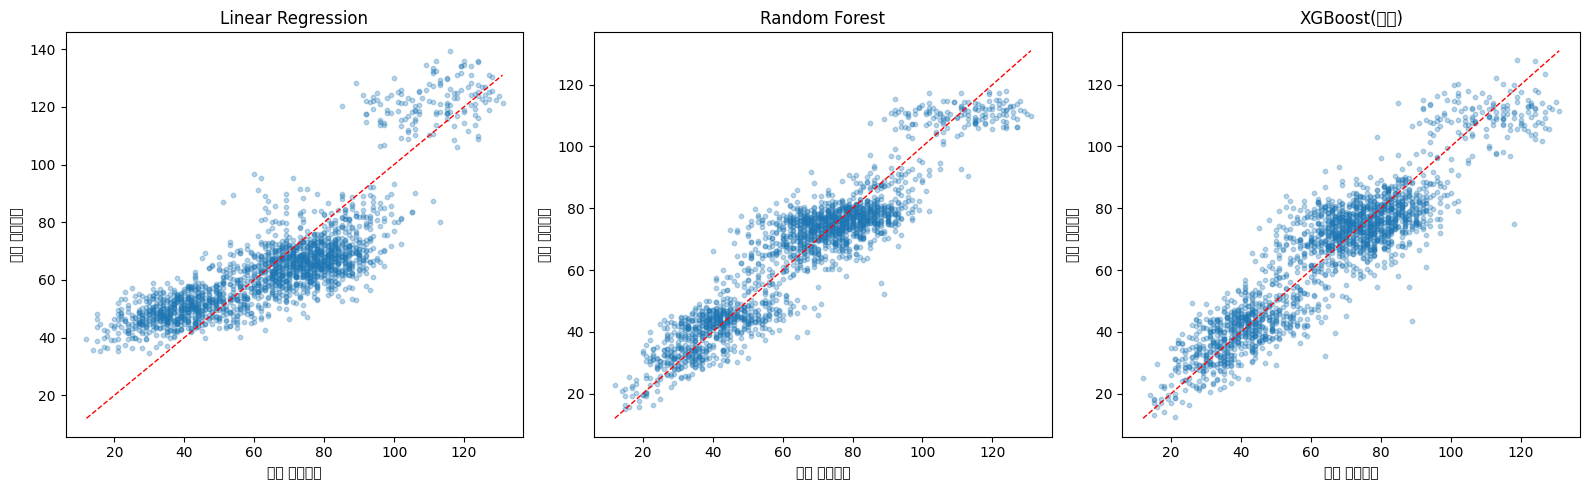

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
preds_val = {
    "Linear Regression": lr.predict(X_val_scaled),
    "Random Forest": rf.predict(X_val),
    "XGBoost(기본)": xgb_base.predict(X_val),
}
for ax, (name, y_pred) in zip(axes, preds_val.items()):
    ax.scatter(y_val, y_pred, alpha=0.3, s=10)
    lims = [y_val.min(), y_val.max()]
    ax.plot(lims, lims, color="red", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("실제 거래건수")
    ax.set_ylabel("예측 거래건수")

plt.tight_layout()
plt.show()

## 5. 튜닝 방법 비교 — 수동 Validation 탐색 / RandomizedSearchCV / GridSearchCV / Optuna

네 가지 방법 모두 Train(60%) 또는 Train+Validation(80%, `X_trainval`)에서만 탐색하고, Test는 6번 섹션에서 각 방법당 **단 한 번만** 평가함.

### 5-1. 수동 Validation 탐색

In [6]:
import itertools

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [5, 7],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.8, 1.0],
}
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

val_results = []
for params in combinations:
    model = XGBRegressor(random_state=42, **params)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_results.append({**params, "Val_R2": r2_score(y_val, val_pred)})

val_results_df = pd.DataFrame(val_results).sort_values("Val_R2", ascending=False)
best_params_manual = val_results_df.iloc[0][list(param_grid.keys())].to_dict()
best_params_manual = {k: int(v) if k in ["n_estimators", "max_depth"] else v for k, v in best_params_manual.items()}

manual_model = XGBRegressor(random_state=42, **best_params_manual)
manual_model.fit(X_train, y_train)

print("수동 탐색 최적 파라미터:", best_params_manual)
print("Validation 최고 R²:", val_results_df.iloc[0]["Val_R2"])

수동 탐색 최적 파라미터: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.8}
Validation 최고 R²: 0.8642473220825195


### 5-2. RandomizedSearchCV (Train+Validation 기준 교차검증)

In [7]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=15, scoring="r2", cv=3,
    random_state=42, n_jobs=-1, verbose=0,
)
random_search.fit(X_trainval, y_trainval)

print("RandomizedSearchCV 최적 파라미터:", random_search.best_params_)
print("교차검증 최고 R²:", random_search.best_score_)

RandomizedSearchCV 최적 파라미터: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
교차검증 최고 R²: 0.8640898863474528


### 5-3. GridSearchCV (Train+Validation 기준 교차검증)

In [8]:
grid_param = {
    "n_estimators": [200, 500],
    "max_depth": [5, 7],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.8, 1.0],
}

t0 = time.time()
grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=grid_param, scoring="r2", cv=3, n_jobs=-1,
)
grid_search.fit(X_trainval, y_trainval)
print(f"GridSearchCV 소요시간: {time.time()-t0:.1f}초")
print("최적 파라미터:", grid_search.best_params_)
print("교차검증 최고 R²:", grid_search.best_score_)

GridSearchCV 소요시간: 43.8초
최적 파라미터: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
교차검증 최고 R²: 0.8660968740781149


### 5-4. Optuna (베이지안 최적화, Train+Validation 기준 교차검증)

In [9]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    model = XGBRegressor(random_state=42, **params)
    scores = cross_val_score(model, X_trainval, y_trainval, cv=3, scoring="r2")
    return scores.mean()

t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=12, show_progress_bar=False)
print(f"Optuna 소요시간: {time.time()-t0:.1f}초")
print("최적 파라미터:", study.best_params)
print("교차검증 최고 R²:", study.best_value)

optuna_model = XGBRegressor(random_state=42, **study.best_params)
optuna_model.fit(X_trainval, y_trainval)

Optuna 소요시간: 33.3초
최적 파라미터: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.013399060561509796, 'subsample': 0.8736932106048627, 'colsample_bytree': 0.7760609974958406}
교차검증 최고 R²: 0.8641193906466166


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7760609974958406
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

## 6. Test 최초이자 마지막 평가 — 네 가지 튜닝 방법 최종 비교

여기서 각 방법의 최종 모델을 Test로 **딱 한 번씩만** 평가함. 이 결과를 보고 위 튜닝 단계로 돌아가 파라미터를 다시 바꾸지 않음(Test 오염 방지).

In [10]:
method_results = pd.DataFrame([
    {"방법": "수동 Validation 탐색", "Test_R2": r2_score(y_test, manual_model.predict(X_test))},
    {"방법": "RandomizedSearchCV", "Test_R2": r2_score(y_test, random_search.best_estimator_.predict(X_test))},
    {"방법": "GridSearchCV", "Test_R2": r2_score(y_test, grid_search.best_estimator_.predict(X_test))},
    {"방법": "Optuna", "Test_R2": r2_score(y_test, optuna_model.predict(X_test))},
])
method_results = method_results.sort_values("Test_R2", ascending=False).reset_index(drop=True)
method_results.round(4)

,방법,Test_R2
0,GridSearchCV,0.8576
1,RandomizedSearchCV,0.8568
2,수동 Validation 탐색,0.8559
3,Optuna,0.8557


## 7. 최종 모델 확정

위 비교에서 Test R²가 가장 높은 모델을 최종 모델(`final_model`)로 확정함. 이후 활동성 갭 계산과 비즈니스 적용은 모두 이 최종 모델 기준으로 진행함.

In [11]:
final_method_name = method_results.iloc[0]["방법"]
final_models = {
    "수동 Validation 탐색": manual_model,
    "RandomizedSearchCV": random_search.best_estimator_,
    "GridSearchCV": grid_search.best_estimator_,
    "Optuna": optuna_model,
}
final_model = final_models[final_method_name]

train_r2_final = r2_score(y_train, final_model.predict(X_train))
val_r2_final = r2_score(y_val, final_model.predict(X_val))
test_r2_final = r2_score(y_test, final_model.predict(X_test))
test_mae_final = mean_absolute_error(y_test, final_model.predict(X_test))
test_rmse_final = mean_squared_error(y_test, final_model.predict(X_test)) ** 0.5

print(f"최종 선정 방법: {final_method_name}")
print(f"Train R²: {train_r2_final:.4f} / Validation R²: {val_r2_final:.4f} / Test R²: {test_r2_final:.4f}")
print(f"Test MAE: {test_mae_final:.2f} / Test RMSE: {test_rmse_final:.2f}")

최종 선정 방법: GridSearchCV
Train R²: 0.8901 / Validation R²: 0.8893 / Test R²: 0.8576
Test MAE: 6.97 / Test RMSE: 8.73


## 8. 최종 모델 Feature Importance

In [12]:
importance_final = pd.Series(final_model.feature_importances_, index=X.columns)
importance_final.sort_values(ascending=False).head(15)

Total_Trans_Amt             0.695230
Marital_Status_Married      0.036583
Customer_Age                0.018525
Total_Amt_Chng_Q4_Q1        0.015935
Total_Relationship_Count    0.013647
Credit_Limit                0.012829
Total_Revolving_Bal         0.012573
상품당_관계밀도                    0.012560
Avg_Open_To_Buy             0.011441
Gender_M                    0.009821
연령대_30대                     0.009778
문의_대비_보유기간                  0.009694
Card_Category_Gold          0.008221
Contacts_Count_12_mon       0.008029
Avg_Utilization_Ratio       0.007502
dtype: float32

## 9. 비즈니스 적용 — '예상 활동수준 대비 실제 활동' 격차 기반 조기경보

최종 모델로 Test셋 고객들의 예측 거래건수를 계산하고, 실제 거래건수와의 차이(활동성 갭)를 구함. 갭이 클수록(음수) 예측 대비 활동이 급감했다는 뜻이며, 이 값이 실제 이탈과 관련 있는지 검증함.

※ 여기서부터는 위에서 정의한 하나의 Test셋(`X_test`, 2단계 분할에서 나온 20%)만 사용하므로, 이후 계산되는 활동성 갭은 노트북 전체에서 단 하나의 기준으로 일관되게 유지됨.

In [13]:
gap_df = pd.DataFrame({
    "고객ID": X_test.index,
    "실제_거래건수": y_test.values,
    "예측_거래건수": final_model.predict(X_test),
})
gap_df["활동성_갭"] = gap_df["실제_거래건수"] - gap_df["예측_거래건수"]
gap_df["실제_이탈여부"] = df.loc[X_test.index, "Target"].values

gap_df.describe()[["활동성_갭"]]

,활동성_갭
count,2026.000000
mean,-0.110330
std,8.731369
min,-31.333054
25%,-6.044299
50%,-0.131151
75%,5.826974
max,31.240612


## 10. 조기경보 대상 — 활동성 갭이 가장 큰(음수) 고객 Top 15

In [14]:
early_warning = gap_df.sort_values("활동성_갭").head(15)
early_warning

,고객ID,실제_거래건수,예측_거래건수,활동성_갭,실제_이탈여부
377,4999,34,65.333054,-31.333054,1
382,9326,81,110.835503,-29.835503,0
1150,9759,54,83.732933,-29.732933,1
358,10048,58,86.323029,-28.323029,1
1990,9375,57,84.719383,-27.719383,1
244,10099,88,115.472092,-27.472092,0
1112,9240,44,70.410873,-26.410873,1
732,9149,42,67.028290,-25.028290,1
1025,8999,40,64.638710,-24.638710,1
950,4681,48,72.554932,-24.554932,0


## 11. 검증 — 활동성 갭이 실제 이탈과 관련 있는가

연속값 기준 상관계수·로지스틱 회귀 계수와, 5구간(qcut) 기준 구간별 실제 이탈률을 함께 확인함. qcut은 구간당 표본이 적어(약 400명) 노이즈에 민감할 수 있으므로, 연속값 기준 지표를 함께 봄으로써 교차검증함.

In [15]:
corr = gap_df["활동성_갭"].corr(gap_df["실제_이탈여부"])
lr_check = LogisticRegression().fit(gap_df[["활동성_갭"]], gap_df["실제_이탈여부"])

print(f"활동성 갭과 이탈여부의 상관계수: {corr:.3f}")
print(f"로지스틱 회귀 계수: {lr_check.coef_[0][0]:.4f} (음수면 갭이 작을수록 이탈위험 높다는 뜻)")

활동성 갭과 이탈여부의 상관계수: -0.171
로지스틱 회귀 계수: -0.0549 (음수면 갭이 작을수록 이탈위험 높다는 뜻)


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 44077 (\N{HANGUL SYLLABLE GAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_540/994575037.py:14: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfon

findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44077 (\N{HANGUL SYLLABLE GAEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Malgun Gothic' not found.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


갭 구간별 실제 이탈률(%):
갭_구간
1_매우낮음(예측대비 급감)    23.6
2_낮음               19.3
3_보통               18.5
4_높음               12.8
5_매우높음(예측대비 초과)     6.4
Name: 실제_이탈여부, dtype: float64


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


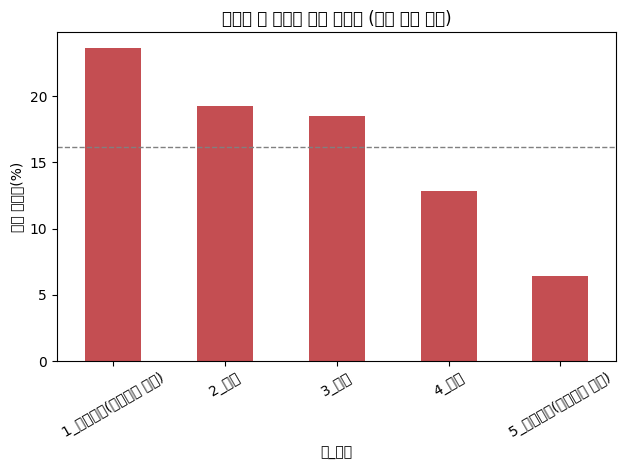

In [16]:
gap_df["갭_구간"] = pd.qcut(
    gap_df["활동성_갭"], q=5,
    labels=["1_매우낮음(예측대비 급감)", "2_낮음", "3_보통", "4_높음", "5_매우높음(예측대비 초과)"]
)

churn_rate_by_gap = gap_df.groupby("갭_구간", observed=True)["실제_이탈여부"].mean() * 100
print("갭 구간별 실제 이탈률(%):")
print(churn_rate_by_gap.round(1))

churn_rate_by_gap.plot(kind="bar", color="#C44E52", rot=30)
plt.ylabel("실제 이탈률(%)")
plt.title("활동성 갭 구간별 실제 이탈률 (최종 모델 기준)")
plt.axhline(gap_df["실제_이탈여부"].mean()*100, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

## 정리

- 피처 엔지니어링 → 6:2:2 분할 → 베이스라인 비교 → 네 가지 튜닝 방법 비교 → 최종 모델 확정 → 활동성 갭 계산까지, 하나의 Train/Validation/Test 기준으로 처음부터 끝까지 일관되게 진행함.
- Test셋은 튜닝 과정에서 전혀 사용하지 않았고, 6번 섹션에서 방법별로 각각 단 한 번씩만 평가해 오염을 방지함.
- 활동성 갭과 실제 이탈여부의 관계는 연속값 기준 상관계수와 5구간 qcut 기준을 함께 확인해, 구간별 그래프가 다소 들쭉날쭉하더라도 전반적인 방향성(음의 상관)은 일관되게 유지되는지 교차검증함.
- 이 최종 모델과 활동성 갭 결과를 07_integration.ipynb의 회귀 파트로 반영하면 됨.